In [4]:
import geopandas as gpd

usaquen_test = gpd.read_file("../data/raw/limites/loca.json")

print(f"Número de filas: {len(usaquen_test)}")
print(f"Tipo de geometría: {usaquen_test.geom_type.unique()}")
print(f"CRS: {usaquen_test.crs}")
print(f"Bounds: {usaquen_test.total_bounds}")
print(usaquen_test.columns.tolist())

Número de filas: 20
Tipo de geometría: <StringArray>
['Polygon']
Length: 1, dtype: str
CRS: EPSG:4686
Bounds: [-74.44977953   3.73103034 -73.98653428   4.8367791 ]
['OBJECTID', 'LocNombre', 'LocAAdmini', 'LocArea', 'LocCodigo', 'SHAPE_Length', 'SHAPE_Area', 'geometry']


In [5]:
print(usaquen_test['LocNombre'].unique())

<StringArray>
[    'ANTONIO NARIÑO',         'TUNJUELITO', 'RAFAEL URIBE URIBE',
         'CANDELARIA',     'BARRIOS UNIDOS',        'TEUSAQUILLO',
      'PUENTE ARANDA',       'LOS MARTIRES',            'SUMAPAZ',
            'USAQUEN',          'CHAPINERO',           'SANTA FE',
      'SAN CRISTOBAL',               'USME',     'CIUDAD BOLIVAR',
               'BOSA',            'KENNEDY',           'FONTIBON',
           'ENGATIVA',               'SUBA']
Length: 20, dtype: str


In [6]:
usaquen_filtrado = usaquen_test[usaquen_test['LocNombre'] == 'USAQUEN']  
print(len(usaquen_filtrado))  # debe dar 1

1


In [7]:
usaquen_filtrado = usaquen_filtrado.to_crs(epsg=4326)
print(usaquen_filtrado.crs)
print(usaquen_filtrado.total_bounds)

EPSG:4326
[-74.05724703   4.66366974 -74.00040412   4.82584129]


In [9]:
usaquen_polygon = usaquen_filtrado.geometry.iloc[0]
print(f"Tipo: {usaquen_polygon.geom_type}")
print(f"¿Válido?: {usaquen_polygon.is_valid}")

Tipo: Polygon
¿Válido?: True


In [10]:
import osmnx as ox

G_oficial = ox.graph_from_polygon(usaquen_polygon, network_type="all")
nodes_oficial, edges_oficial = ox.graph_to_gdfs(G_oficial)

print(f"Nodos (oficial): {len(G_oficial.nodes)}")
print(f"Aristas (oficial): {len(G_oficial.edges)}")

Nodos (oficial): 14096
Aristas (oficial): 37789


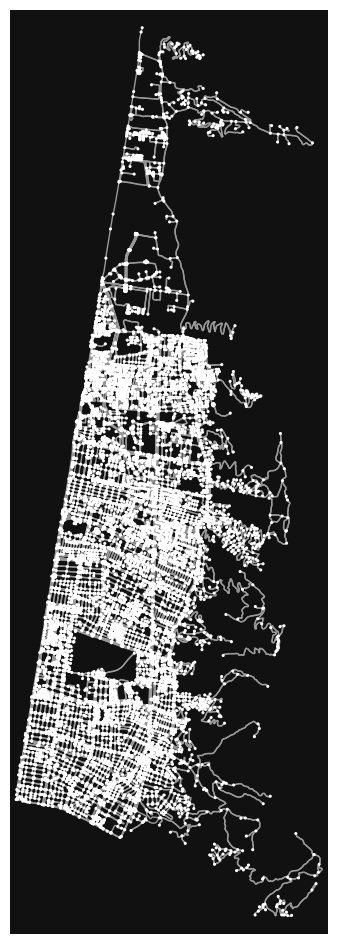

In [11]:
fig, ax = ox.plot_graph(G_oficial, node_size=5, figsize=(12, 12))
fig.savefig("../docs/f1/red_usaquen_oficial.png", dpi=200)

In [12]:
edges_oficial['highway'].value_counts()

highway
footway                             13634
residential                         10402
service                              6549
cycleway                             1552
tertiary                             1290
secondary                            1231
primary                              1224
steps                                 280
[residential, footway]                254
path                                  224
primary_link                          186
trunk                                 185
track                                 132
[steps, footway]                      132
trunk_link                             86
[service, footway]                     56
unclassified                           56
pedestrian                             54
corridor                               50
[footway, corridor]                    45
[residential, service]                 38
[corridor, footway]                    27
secondary_link                         21
[residential, steps]      

In [13]:
edges_oficial.columns.tolist()

['osmid',
 'highway',
 'oneway',
 'reversed',
 'length',
 'lanes',
 'name',
 'geometry',
 'maxspeed',
 'access',
 'bridge',
 'ref',
 'service',
 'width',
 'junction',
 'tunnel']

In [14]:
for col in ['maxspeed', 'lanes', 'oneway', 'name']:
    if col in edges_oficial.columns:
        pct = edges_oficial[col].notna().mean() * 100
        print(f"{col}: {pct:.1f}% de las vías tienen este dato")
    else:
        print(f"{col}: no existe en el dataset")

maxspeed: 23.2% de las vías tienen este dato
lanes: 27.8% de las vías tienen este dato
oneway: 100.0% de las vías tienen este dato
name: 41.9% de las vías tienen este dato


## Hallazgos - Evaluación red OSM Usaquén (versión con límite oficial)

**Fuente del límite geográfico:** Dataset "Localidad Bogotá D.C." — Secretaría 
Distrital de Planeación, portal Datos Abiertos Bogotá. CRS original: EPSG:4686 
(MAGNA-SIRGAS), convertido a EPSG:4326 para compatibilidad con osmnx/SUMO.

**Red vial:** Descargada de OpenStreetMap y recortada exactamente al polígono 
oficial de la localidad mediante `osmnx.graph_from_polygon()`.

- Total de nodos (intersecciones): 14096
- Total de segmentos viales (edges): 37789
- Tipos de vía predominantes: footway, residential, service y cycleway

**Cobertura de atributos:**
- Velocidad máxima (maxspeed): 23.2% de las vías tienen este dato
- Número de carriles (lanes): 27.8% de las vías tienen este dato
- Sentido de circulación (oneway): 100.0% de las vías tienen este dato
- Nombre de vía (name): 41.9% de las vías tienen este dato

**Observaciones sobre calidad geométrica:**

- La forma general de la red sigue el contorno alargado y estrecho de Usaquén, consistente con el límite oficial usado para el recorte.

- La densidad de la red es heterogénea: la zona occidental (más plana, urbanizada) presenta una malla vial en cuadrícula densa y bien conectada. La zona oriental, en cambio, muestra vías más dispersas, ramificadas y con múltiples terminaciones sueltas (dead-ends), consistente con la topografía de los Cerros Orientales que bordean la localidad por el oriente — zona de menor densidad vial real y,  probablemente, de menor nivel de detalle en el mapeo de OSM.

- Se identifica un área vacía sin cobertura vial en la zona centro-occidental de la red (polígono negro sin trazado). Esta zona corresponde al Country Club.

- Se observan varios segmentos "sueltos" (vías que terminan sin conectar a la red principal) en el borde oriental, especialmente en el tramo norte de la localidad. Esto es esperable en zonas de transición entre lo urbano y lo rural, pero debe tenerse en cuenta como limitación de conectividad para la fase de ruteo (duarouter).

**Conclusión:**

La red vial recortada al límite oficial de Usaquén presenta una estructura consistente con la geografía real de la localidad: alta densidad y buena conectividad en la franja urbana occidental (donde se concentrará la mayor parte de la demanda de viajes), y menor densidad/conectividad hacia los Cerros Orientales, lo cual es coherente con el uso del suelo de esa zona y no representa un error del proceso de extracción.

Antes de avanzar a la Fase 2 (procesamiento con netconvert):
1. Evaluar si los segmentos colgantes del borde oriental requieren limpieza o si deben conservarse como límite natural de la red simulable.
2. Confirmar que la cobertura de atributos (maxspeed, lanes) sea suficiente para que netconvert asigne capacidades por defecto razonables en los tramos con datos faltantes.

